In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from daemon_analysis_tools.io.csv_handler import load_and_process_csv
from daemon_analysis_tools.io.yaml_handler import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [8]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

False ['Research Data Policy (RDP) exists.'] 1
False ['Research Data Policy (RDP) exists.'] 1
False ['Research Data Policy (RDP) exists.'] 1
No discrepancies detected.
False ['Data sharing encouraged but optional.'] 1
False ['Data sharing encouraged but optional.'] 1
False ['Data sharing encouraged but optional.'] 1
No discrepancies detected.
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
No discrepancies detected.
False ['Mentioned in the RDP but optional.'] 1
False ['Mentioned in the RDP but optional.'] 1
False ['Mentioned in the RDP but optional.'] 1
No discrepancies detected.
False ['No mention of DOIs or other persistent identifiers for datasets or codes.'] 1
False ['No mention of DOIs or other persistent identifiers for datasets or codes.'] 1
False ['No mention of DOIs or other persistent identifiers for 

In [9]:
for publisher, journals in grouped_questions.items():
    for journal, data in journals.items():
        for question, answer in data.items():
            if answer.has_discrepancies():
                print(publisher, journal, question, answer.discrepancy_reason)

False ['Research Data Policy (RDP) exists.'] 1
False ['Data sharing encouraged but optional.'] 1
False ['Public data sharing on a FAIR repository not mentioned in RDP.'] 1
False ['Mentioned in the RDP but optional.'] 1
False ['No mention of DOIs or other persistent identifiers for datasets or codes.'] 1
False ['Required data must be available prior to official publication.'] 1
False ['Data sharing in supplementary material or hosting by journal recommended in RDP.'] 1
False ['No mention of data/code licenses in RDP.'] 1
False ['Data sharing policy not mentioned in refereeing guidelines.'] 1
False ['no text.'] 1
False ['crystal structures'] 1
False ['Code sharing required.'] 1
False ['Journal policies require stating all dependencies and their versions that were used to run computational experiments.'] 1
False ['Journal policies encourage/recommend a persistent identifier or specifying a version of developed code.'] 1
False ['The journal policies do not mention any code quality standard

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

ACS 15
AIP 14
APS 11
Bentham Science 6
Elsevier 9
Frontiers 7
IEEE 15
IOP 9
MDPI 15
Optica 9
Pleiades Publishing 9
RSC 9
Springer Nature 10
Taylor & Francis 15
Wiley 15


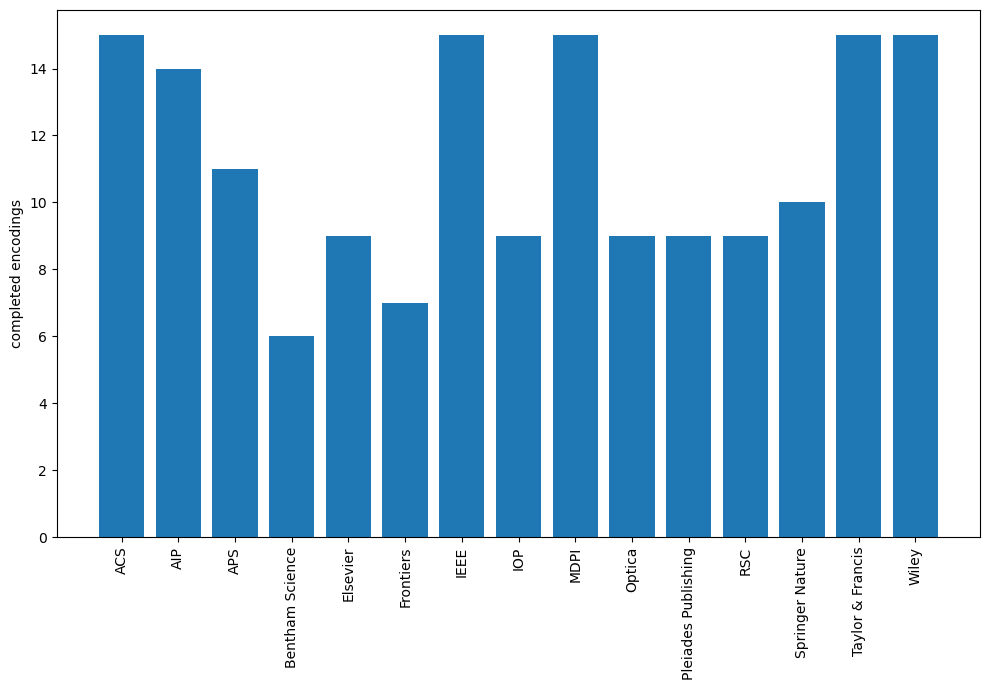

In [10]:
import matplotlib.pyplot as plt

n_journals = {}

x = []
y = []

for publisher, journals in grouped_questions.items():
    n_journals[publisher] = len(journals)

for publisher, num in n_journals.items():
    x.append(publisher)
    y.append(num)
    print(publisher, num)

x_0 = list(range(len(x)))

# Creating plot
fig = plt.figure(figsize=(10, 7))
plt.bar(x_0, y)
plt.xticks(x_0, x, rotation=90)
plt.ylabel("completed encodings")
plt.tight_layout()

fig.savefig("../../data/processed/number_of_encodings.pdf")